# Bond Pricing & Interest Rate Sensitivity Tool

This project prices zero-coupon and coupon bonds and analyzes their sensitivity to interest rate changes using duration and convexity measures.

Libraries used:
- NumPy
- Pandas
- Matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def Bond_Price(Face_Value, YTM, C, T, Freq):
    # Face_Value = amount repaid at maturity
    # YTM = yield to maturity as a decimal
    # C = annual coupon rate as a decimal
    # T = maturity in years
    # Freq = frequency of coupon payments per year (=1 if ZC)

    if C == 0:          # Zero-Coupon bond
        if 0 < T < 1:
            Price = Face_Value / (1 + YTM * T)
        else:
            Price = Face_Value / ((1 + YTM)**T)
        return round(Price, 4)

    else:               # Coupon Bond
        Price = 0
        for i in range(1, (T * Freq) + 1):
            
            # Discount coupon payments before maturity
            if i < (T * Freq):
                Discounted_Cash_Flows = (C * Face_Value / Freq) / ((1 + (YTM / Freq)) ** i)
            
            # Last payment = final coupon + principal
            else:
                Discounted_Cash_Flows = ((C * Face_Value / Freq) + Face_Value) / ((1 + (YTM / Freq))**i)
            
            Price += Discounted_Cash_Flows
    
    return round(Price, 4)

In [3]:
def cash_flows_list(Face_Value, C, T, Freq):
    # Face_Value = amount repaid at maturity
    # C = annual coupon rate as a decimal
    # T = maturity in years
    # Freq = frequency of coupon payments per year
    
    my_list = []
    for i in range(1, (T * Freq)+1):

        # Regular coupon payments
        if i < (T * Freq):
            Cash_Flows = (C/Freq) * Face_Value
            my_list.append(Cash_Flows)
            
        # Last payment = final coupon + principal
        else:
            Last_Cash_Flows = ((C/Freq) * Face_Value) + Face_Value
            my_list.append(Last_Cash_Flows)

    return my_list

In [4]:
def payment_periods_list(T, Freq):
    # T = maturity in years
    # Freq = frequency of coupon payments per year
    
    my_array = np.arange((1/Freq), T + (1 / Freq), (1/Freq))
    return [float(periods) for periods in my_array]

In [5]:
def discount_factors_list(YTM, T, Freq):
    # YTM = yield to maturity as a decimal
    # T = maturity in years
    # Freq = frequency of coupon payments per year
    
    my_list = []
    for i in range(1, (T * Freq)+1):
        Discount_Factor = 1 / ((1 + (YTM / Freq))**i)
        my_list.append(round(Discount_Factor,4))

    return my_list

In [6]:
def discounted_cash_flows_list(Face_Value, YTM, C, T, Freq):
    # Face_Value = amount repaid at maturity
    # YTM = yield to maturity as a decimal
    # C = annual coupon rate as a decimal
    # T = maturity in years
    # Freq = frequency of coupon payments per year

    my_list = []
    
    for i in range(1, T * Freq + 1):

        # Discount regular coupon payments
        if i < T * Freq:
            discounted_cash_flow = (C * Face_Value / Freq) / ((1 + (YTM / Freq)) ** i)
            my_list.append(round(discounted_cash_flow, 4))

        # Discount final coupon + principal
        else:
            discounted_cash_flow = ((C*Face_Value/Freq) + Face_Value) / ((1 + (YTM / Freq)) ** i)
            my_list.append(round(discounted_cash_flow, 4))

    return my_list

In [7]:
def Bond_Cash_Flow_Table(Face_Value, YTM, C, T, Freq):
    # Face_Value = amount repaid at maturity
    # YTM = yield to maturity as a decimal
    # C = annual coupon rate as a decimal
    # T = maturity in years
    # Freq = frequency of coupon payments per year
    
    DF = pd.DataFrame({
                       # Payment dates expressed in years
                       'Period': payment_periods_list(T, Freq),

                       # Bond cash flows paid at each period
                       'Cash Flow' : cash_flows_list(Face_Value, C, T, Freq),

                        # Present value discount coefficients
                       'Discount Factor' : discount_factors_list(YTM, T, Freq),

                       # Present value of each cash flow
                       'Discounted Cash Flow' : discounted_cash_flows_list(Face_Value, YTM, C, T, Freq)})

    return DF

In [8]:
def Macaulay_Duration(Face_Value, YTM, C, T, Freq):
    # Macaulay Duration = weighted average time needed to receive the bond's cash flows
    # Face_Value = amount repaid at maturity
    # YTM = yield to maturity as a decimal
    # C = annual coupon rate as a decimal
    # T = maturity in years
    # Freq = frequency of coupon payments per year

    Weighted_DCF = 0
    
    for i in range(1, T*Freq + 1):

        # Time expressed in years
        Time = i / Freq

        if i < T * Freq:
            DCF = (C * Face_Value / Freq) / ((1 + YTM / Freq) ** i)

        else:
            DCF = ((C * Face_Value / Freq) + Face_Value)/ ((1 + YTM / Freq) ** i)

        Weighted_DCF += Time * DCF

    Price = Bond_Price(Face_Value, YTM, C, T, Freq)

    return round(Weighted_DCF / Price, 4)

In [9]:
def Modified_Duration(Face_Value, YTM, C, T, Freq):
    # Modified Duration = approximate sensitivity of bond price to yield changes
    # Face_Value = amount repaid at maturity
    # YTM = yield to maturity as a decimal
    # C = annual coupon rate as a decimal
    # T = maturity in years
    # Freq = frequency of coupon payments per year
    
    return round((Macaulay_Duration(Face_Value, YTM, C, T, Freq) / (1 + YTM / Freq)), 4)

In [10]:
def Bonds_Convexity(Face_Value, YTM, C, T, Freq):
    # Convexity = measures the curvature between bond price and yield
    # Face_Value = amount repaid at maturity
    # YTM = yield to maturity as a decimal
    # C = annual coupon rate as a decimal
    # T = maturity in years
    # Freq = frequency of coupon payments per year

    Convexity_Sum = 0

    for i in range(1, T * Freq + 1):
        
        if i < T * Freq:
            DCF = (C * Face_Value / Freq) / ((1 + (YTM / Freq)) ** i)
        else:
            DCF = ((C * Face_Value / Freq) + Face_Value) / ((1 + (YTM / Freq)) ** i)

        Convexity_Sum += i * (i + 1) * DCF

    Price = Bond_Price(Face_Value, YTM, C, T, Freq)

    return round(Convexity_Sum / (Price * ((1 + YTM / Freq) ** 2) * (Freq ** 2)), 4)

In [11]:
def Bond_Summary(Face_Value, YTM, C, T, Freq):
    # Face_Value = amount repaid at maturity
    # YTM = yield to maturity as a decimal
    # C = annual coupon rate as a decimal
    # T = maturity in years
    # Freq = frequency of coupon payments per year

    DF = pd.DataFrame({'Bond Price' : [Bond_Price(Face_Value, YTM, C, T, Freq)],
                       'Macaulay Duration' : [Macaulay_Duration(Face_Value, YTM, C, T, Freq)],
                       'Modified Duration' : [Modified_Duration(Face_Value, YTM, C, T, Freq)],
                       'Convexity' : [Bonds_Convexity(Face_Value, YTM, C, T, Freq)]})
    
    return DF.style.hide(axis='index')               

In [12]:
def pct_price_change_Mod_Duration(Face_Value, YTM, C, T, Freq, YTM_pct_change):
    # Modified Duration = approximate sensitivity of bond price to yield changes
    # Face_Value = amount repaid at maturity
    # YTM = yield to maturity as a decimal
    # C = annual coupon rate as a decimal
    # T = maturity in years
    # Freq = frequency of coupon payments per year
    # YTM_pct_change = change in yield expressed as a decimal

    ModDuration = Modified_Duration(Face_Value, YTM, C, T, Freq)
    return -ModDuration * YTM_pct_change

In [13]:
def pct_price_change_Convexity(Face_Value, YTM, C, T, Freq, YTM_pct_change):
    # Convexity = measures the curvature between bond price and yield
    # Face_Value = amount repaid at maturity
    # YTM = yield to maturity as a decimal
    # C = annual coupon rate as a decimal
    # T = maturity in years
    # Freq = frequency of coupon payments per year
    # YTM_pct_change = change in yield expressed as a decimal

    ModDuration = Modified_Duration(Face_Value, YTM, C, T, Freq)
    Convexity = Bonds_Convexity(Face_Value, YTM, C, T, Freq)
    
    return -ModDuration * YTM_pct_change + 0.5 * Convexity * (YTM_pct_change ** 2)

In [14]:
def Bond_Price_pct_change(Face_Value, YTM, C, T, Freq, YTM_pct_change):
    # Face_Value = amount repaid at maturity
    # YTM = yield to maturity as a decimal
    # C = annual coupon rate as a decimal
    # T = maturity in years
    # Freq = frequency of coupon payments per year
    # YTM_pct_change = absolute change in yield as a decimal

    initial_Price = Bond_Price(Face_Value, YTM, C, T, Freq)
    
    new_YTM = YTM_pct_change + YTM
    new_Price = Bond_Price(Face_Value, new_YTM, C, T, Freq)

    return (new_Price - initial_Price) / initial_Price 

In [15]:
def Sensitivity_Analysis(Face_Value, YTM, C, T, Freq, yield_shocks_list):
    # Face_Value = amount repaid at maturity
    # YTM = yield to maturity as a decimal
    # C = annual coupon rate as a decimal
    # T = maturity in years
    # Freq = frequency of coupon payments per year
    # yield_shocks_list = list of yield changes expressed as decimals

    Exact_Change_list = []
    Duration_Approx_list = []
    Duration_and_Convexity_Approx_list = []

    for yield_shock in yield_shocks_list:
        
        Exact_Change = Bond_Price_pct_change(Face_Value, YTM, C, T, Freq, yield_shock)
        Exact_Change_list.append(Exact_Change)
        
        Duration_Approx = pct_price_change_Mod_Duration(Face_Value, YTM, C, T, Freq, yield_shock)
        Duration_Approx_list.append(Duration_Approx)
        
        Duration_and_Convexity_Approx = pct_price_change_Convexity(Face_Value, YTM, C, T, Freq, yield_shock)
        Duration_and_Convexity_Approx_list.append(Duration_and_Convexity_Approx)

    DF = pd.DataFrame({'Yield Shock' : yield_shocks_list,
                       'Exact Change' : Exact_Change_list,
                       'Duration Approx' : Duration_Approx_list,
                       'Duration + Convexity Approx' : Duration_and_Convexity_Approx_list})

    return DF

In [16]:
def Bond_Price_vs_Yield_Visualization(Face_Value, YTM, C, T, Freq, yield_shocks_list):
    # Face_Value = amount repaid at maturity
    # YTM = yield to maturity as a decimal
    # C = annual coupon rate as a decimal
    # T = maturity in years
    # Freq = frequency of coupon payments per year
    # yield_shocks_list = list of yield changes expressed as decimals
    
    current_price = Bond_Price(Face_Value, YTM, C, T, Freq)
    
    Prices = []
    Yields = []
    for yield_shocks in yield_shocks_list:
        new_yield = YTM + yield_shocks
        Prices.append(Bond_Price(Face_Value, new_yield, C, T, Freq))
        Yields.append(new_yield)
    
    plt.figure(figsize = (10, 6))
    plt.plot(Yields, Prices, 'ok-', linewidth=2, label='Price for yield scenarios')
    plt.plot(YTM, current_price, 'or', markersize=9, label='Current YTM and Price')
    
    plt.legend()
    plt.xlabel('Yield (as a decimal)')
    plt.ylabel('Bond Price')
    plt.title('Bond Price vs Yield (everything else fixed)')
    plt.show()

In [17]:
def Price_Approximation_Visualization(Face_Value, YTM, C, T, Freq, yield_shocks_list):
    # Face_Value = amount repaid at maturity
    # YTM = yield to maturity as a decimal
    # C = annual coupon rate as a decimal
    # T = maturity in years
    # Freq = frequency of coupon payments per year
    # yield_shocks_list = list of yield changes expressed as decimals

    # Current bond price
    current_Price = Bond_Price(Face_Value, YTM, C, T, Freq)
    
    exact_prices = []
    duration_prices = []
    convexity_prices = []
    Yields = []
    
    for yield_shock in yield_shocks_list:
        
        # New yield after the shock
        new_yield = YTM + yield_shock
        Yields.append(new_yield)

        # Exact repriced bond value
        exact_prices.append(Bond_Price(Face_Value, new_yield, C, T, Freq))

        # Price estimated with modified duration
        duration_prices.append(current_Price * (1 + pct_price_change_Mod_Duration(Face_Value, YTM, C, T, Freq, yield_shock)))

        # Price estimated with duration and convexity
        convexity_prices.append(current_Price * (1 + pct_price_change_Convexity(Face_Value, YTM, C, T, Freq, yield_shock)))

    
    plt.figure(figsize = (10, 6)) 
    
    # Exact bond prices
    plt.plot(Yields, exact_prices, 'ok-', linewidth=2, label='Exact Bond Price')

    # Duration approximation
    plt.plot(Yields, duration_prices, linestyle='--', color='darkturquoise', linewidth=2, label='Modified Duration Approximation')

    # Duration + convexity approximation
    plt.plot(Yields, convexity_prices, linestyle='--', color='mediumorchid', linewidth=2, label='Duration & Convexity Approximation')

    # Current bond price
    plt.plot(YTM, current_Price, 'or', markersize=9, label='Current YTM and Price')

    plt.legend()
    plt.xlabel('Yield (as a decimal)')
    plt.ylabel('Bond Price')
    plt.title('Exact Bond Price vs Duration-Based Approximations')
    
    plt.grid()
    plt.show()

In [18]:
def Functions_Description_Table():

    functions_list = ['Functions_Description_Table()',
                      'Bond_Price(Face_Value, YTM, C, T, Freq)',
                      'Bond_Summary(Face_Value, YTM, C, T, Freq)',
                      'Bond_Cash_Flow_Table(Face_Value, YTM, C, T, Freq)',
                      'Sensitivity_Analysis(Face_Value, YTM, C, T, Freq, yield_shocks_list)',
                      'Bond_Price_vs_Yield_Visualization(Face_Value, YTM, C, T, Freq, yield_shocks_list)',
                      'Price_Approximation_Visualization(Face_Value, YTM, C, T, Freq, yield_shocks_list)',
                      'Bond_Price_pct_change(Face_Value, YTM, C, T, Freq, YTM_pct_change)',
                      'Macaulay_Duration(Face_Value, YTM, C, T, Freq)',
                      'Modified_Duration(Face_Value, YTM, C, T, Freq)',
                      'pct_price_change_Mod_Duration(Face_Value, YTM, C, T, Freq, YTM_pct_change)',
                      'Bonds_Convexity(Face_Value, YTM, C, T, Freq)',
                      'pct_price_change_Convexity(Face_Value, YTM, C, T, Freq, YTM_pct_change)',
                      'discounted_cash_flows_list(Face_Value, YTM, C, T, Freq)',
                      'discount_factors_list(YTM, T, Freq)',
                      'payment_periods_list(T, Freq)',
                      'cash_flows_list(Face_Value, C, T, Freq)']

    description_list = ['Displays all functions available in the project',
                        'Computes the price of a zero-coupon or coupon bond',
                        'Displays the main bond analytics in a summary table',
                        'Displays the bond cash flows and discounted cash flows',
                        'Compares exact price changes with duration and convexity approximations',
                        'Plots the relationship between bond price and yield',
                        'Plots exact bond prices against duration-based approximations',
                        'Computes the exact percentage price change after a yield shock',
                        'Computes the Macaulay duration of the bond',
                        'Computes the Modified duration of the bond',
                        'Approximates the percentage price change using modified duration',
                        'Computes the Convexity of the bond',
                        'Approximates the percentage price change using duration and convexity',
                        'Returns the list of discounted cash flows',
                        'Returns the list of discount factors',
                        'Returns the list of payment periods',
                        'Returns the list of bond cash flows']

    DF = pd.DataFrame({'Functions (with inputs) in this notebook' : functions_list,
                       'Function description' : description_list})

    return DF.style.hide(axis='index') 

In [19]:
Functions_Description_Table()

Functions (with inputs) in this notebook,Function description
Functions_Description_Table(),Displays all functions available in the project
"Bond_Price(Face_Value, YTM, C, T, Freq)",Computes the price of a zero-coupon or coupon bond
"Bond_Summary(Face_Value, YTM, C, T, Freq)",Displays the main bond analytics in a summary table
"Bond_Cash_Flow_Table(Face_Value, YTM, C, T, Freq)",Displays the bond cash flows and discounted cash flows
"Sensitivity_Analysis(Face_Value, YTM, C, T, Freq, yield_shocks_list)",Compares exact price changes with duration and convexity approximations
"Bond_Price_vs_Yield_Visualization(Face_Value, YTM, C, T, Freq, yield_shocks_list)",Plots the relationship between bond price and yield
"Price_Approximation_Visualization(Face_Value, YTM, C, T, Freq, yield_shocks_list)",Plots exact bond prices against duration-based approximations
"Bond_Price_pct_change(Face_Value, YTM, C, T, Freq, YTM_pct_change)",Computes the exact percentage price change after a yield shock
"Macaulay_Duration(Face_Value, YTM, C, T, Freq)",Computes the Macaulay duration of the bond
"Modified_Duration(Face_Value, YTM, C, T, Freq)",Computes the Modified duration of the bond


# Examples

In [20]:
print(Bond_Price(100, 0.04, 0.045, 3, 2))    # 3Y coupon bond paying coupons twice a year with a 4.5% coupon rate
print(Bond_Price(100, 0.03, 0, 1, 1))        # One-year zero-coupon bond
print(Bond_Price(100, 0.035, 0.02, 5, 1))    # 5Y coupon bond with a 2% annual coupon rate

101.4004
97.0874
93.2274


In [21]:
# 7Y bond paying semiannual coupons with a 6.5% coupon rate
print(Bond_Price(1000, 0.052, 0.065, 7, 2))
print(Macaulay_Duration(1000, 0.052, 0.065, 7, 2))
print(Modified_Duration(1000, 0.052, 0.065, 7, 2))
print(Bonds_Convexity(1000, 0.052, 0.065, 7, 2))
Bond_Summary(1000, 0.052, 0.065, 7, 2)

1075.4672
5.7867
5.6401
38.4914


Bond Price,Macaulay Duration,Modified Duration,Convexity
1075.467200,5.786700,5.640100,38.491400


In [22]:
# 4Y semi-annual coupon bond with a 6% coupon rate
print(payment_periods_list(4, 2))
print(cash_flows_list(500, 0.06, 4, 2))
print(discount_factors_list(0.045, 4, 2))
print(discounted_cash_flows_list(500, 0.045, 0.06, 4, 2))
Bond_Cash_Flow_Table(500, 0.045, 0.06, 4, 2)

[0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
[15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 515.0]
[0.978, 0.9565, 0.9354, 0.9148, 0.8947, 0.875, 0.8558, 0.8369]
[14.6699, 14.3471, 14.0314, 13.7227, 13.4207, 13.1254, 12.8365, 431.0232]


,Period,Cash Flow,Discount Factor,Discounted Cash Flow
0,0.5,15.0,0.9780,14.6699
1,1.0,15.0,0.9565,14.3471
2,1.5,15.0,0.9354,14.0314
3,2.0,15.0,0.9148,13.7227
4,2.5,15.0,0.8947,13.4207
5,3.0,15.0,0.8750,13.1254
6,3.5,15.0,0.8558,12.8365
7,4.0,515.0,0.8369,431.0232


In [23]:
# 6Y semiannual coupon bond with several yield shock scenarios

my_list = [-0.02, -0.01, -0.005, 0, 0.005, 0.01, 0.02]

print(my_list[0])
print(Bond_Price_pct_change(1000, 0.045, 0.05, 6, 2, my_list[0]))
print(pct_price_change_Mod_Duration(1000, 0.045, 0.05, 6, 2, my_list[0]))
print(pct_price_change_Convexity(1000, 0.045, 0.05, 6, 2, my_list[0]))

Sensitivity_Analysis(1000, 0.045, 0.05, 6, 2, my_list)

-0.02
0.10960083404407779
0.103054
0.10931288


,Yield Shock,Exact Change,Duration Approx,Duration + Convexity Approx
0,-0.020,0.109601,0.103054,0.109313
1,-0.010,0.053126,0.051527,0.053092
2,-0.005,0.026159,0.025764,0.026155
3,0.000,0.000000,-0.000000,0.000000
4,0.005,-0.025376,-0.025764,-0.025372
5,0.010,-0.049996,-0.051527,-0.049962
6,0.020,-0.097063,-0.103054,-0.096795


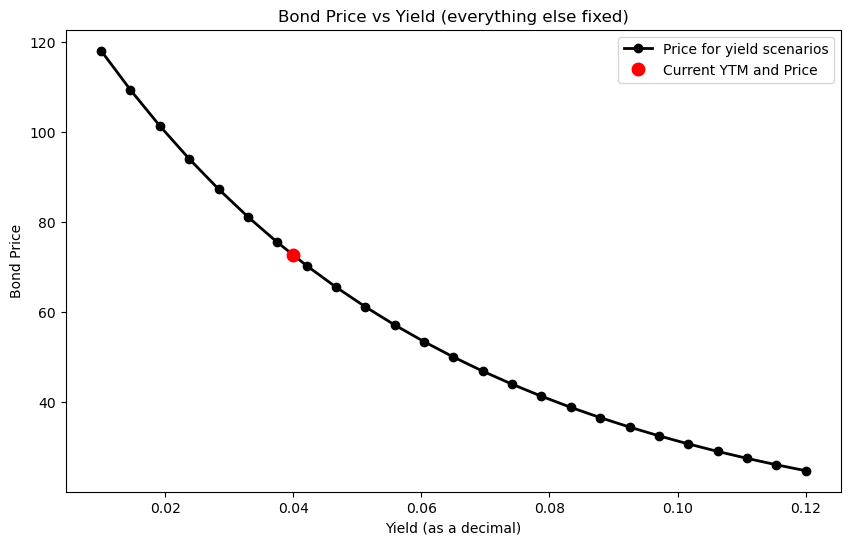

In [24]:
# 20Y semiannual coupon bond used to visualize the convex relationship between price and yield
my_list = np.linspace(-0.03, 0.08, 25)
Bond_Price_vs_Yield_Visualization(100, 0.04, 0.02, 20, 2, my_list)

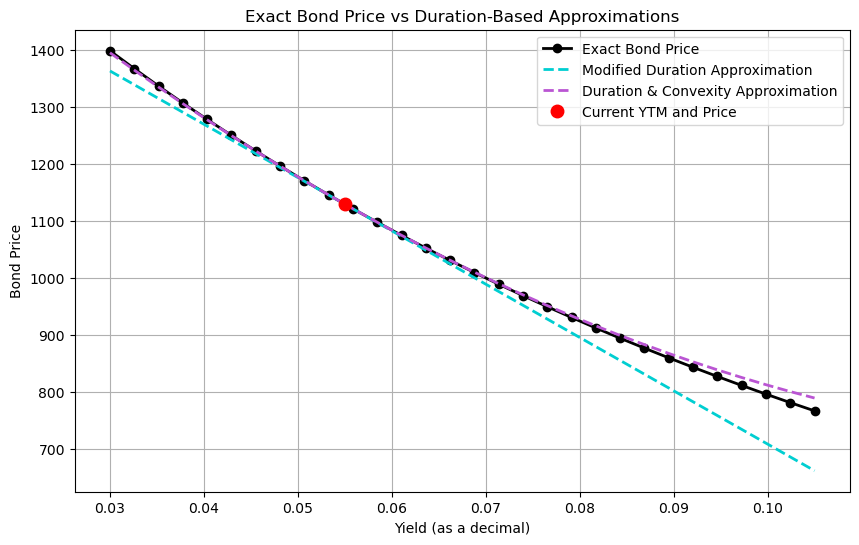

In [25]:
# 12Y annual coupon bond comparing exact bond prices with duration-based approximations under different yield shocks
my_list = np.linspace(-0.025, 0.05, 30)
Price_Approximation_Visualization(1000, 0.055, 0.07, 12, 1, my_list)